# Create Database

In [22]:
import sqlite3
import csv

db_path = "transactions.db"
csv_path = "PS_20174392719_1491204439457_log.csv"
table_name = "trxns"

with sqlite3.connect(db_path) as conn, open(csv_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    header = next(reader)

    placeholders = ", ".join(["?"] * len(header))

    column_types = {
    "step": "INTEGER",
    "type": "TEXT",
    "amount": "REAL",
    "nameOrig": "TEXT",
    "oldbalanceOrg": "REAL",
    "newbalanceOrig": "REAL",
    "nameDest": "TEXT",
    "oldbalanceDest": "REAL",
    "newbalanceDest": "REAL",
    "isFraud": "INTEGER",
    "isFlaggedFraud": "INTEGER"
}
    conn.execute(f'DROP TABLE IF EXISTS {table_name}')
    columns_with_types = ", ".join([f'"{col}" {col_type}' for col, col_type in column_types.items()])
    conn.execute(f'CREATE TABLE {table_name} ({columns_with_types})')
    conn.executemany(
        f'INSERT INTO {table_name} VALUES ({placeholders})',
        [row for row in reader if len(row) == len(header)]
    )


In [23]:
conn = sqlite3.connect("transactions.db")
cursor = conn.cursor()

# List all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
tables = cursor.fetchall()
print("Tables:", tables)

# Show schema of each table
for table_name, in tables:
    print(f"\nSchema for table: {table_name}")
    cursor.execute(f"PRAGMA table_info({table_name})")
    for row in cursor.fetchall():
        print(row)


Tables: [('trxns',)]

Schema for table: trxns
(0, 'step', 'INTEGER', 0, None, 0)
(1, 'type', 'TEXT', 0, None, 0)
(2, 'amount', 'REAL', 0, None, 0)
(3, 'nameOrig', 'TEXT', 0, None, 0)
(4, 'oldbalanceOrg', 'REAL', 0, None, 0)
(5, 'newbalanceOrig', 'REAL', 0, None, 0)
(6, 'nameDest', 'TEXT', 0, None, 0)
(7, 'oldbalanceDest', 'REAL', 0, None, 0)
(8, 'newbalanceDest', 'REAL', 0, None, 0)
(9, 'isFraud', 'INTEGER', 0, None, 0)
(10, 'isFlaggedFraud', 'INTEGER', 0, None, 0)


In [24]:
import pandas as pd

# Connect to the database and read the table into a DataFrame
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query("SELECT COUNT(*) FROM trxns", conn)  # change or remove LIMIT as needed

# Display the data
df

,COUNT(*)
0,6362620


# Set Up Vanna with NVIDIA NIM

In [ ]:
!pip uninstall vanna -y --break-system-packages
!pip install vanna --break-system-packages

In [2]:
from openai import OpenAI
from vanna.openai.openai_chat import OpenAI_Chat
from vanna.chromadb.chromadb_vector import ChromaDB_VectorStore

client = OpenAI(
  base_url = "https://integrate.api.nvidia.com/v1",
  api_key = ""
)

# Define a combined Vanna class
class MyVanna(ChromaDB_VectorStore, OpenAI_Chat):
    def __init__(self, client):
        ChromaDB_VectorStore.__init__(self)
        OpenAI_Chat.__init__(self, client=client, config={"model": "meta/llama-3.1-70b-instruct"})  # pass empty config to avoid NoneType error

# Instantiate
vn = MyVanna(client=client)
vn.connect_to_sqlite("transactions.db")

# Train
Train with Documentation

In [7]:
# Add documentation about your business terminology or definitions.
vn.train(
    documentation="""
    This dataset is used to answer questions about the transactions (trxns) information.
    """
)


vn.train(
    documentation="""
    The trxns table contains transaction records between accounts. Each row represents a single transaction.

    Columns:
    - step: Simulation step (an integer indicating the order of the transaction over time).
    - type: Type of transaction (e.g., 'PAYMENT', 'TRANSFER', 'CASH_OUT', etc.).
    - amount: Transaction amount in USD.
    - nameOrig: Unique identifier of the originator (sender) account.
    - oldbalanceOrg: Account balance of the originator before the transaction.
    - newbalanceOrig: Account balance of the originator after the transaction.
    - nameDest: Unique identifier of the destination (receiver) account.
    - oldbalanceDest: Account balance of the destination before the transaction.
    - newbalanceDest: Account balance of the destination after the transaction.
    - isFraud: Flag indicating whether the transaction was fraudulent (1 = fraud, 0 = not fraud).
    - isFlaggedFraud: Flag indicating whether the transaction was flagged as potentially fraudulent by internal rules.
    """
)


Adding documentation....
Adding documentation....


'ac63abbb-41fb-5ed4-892b-d8ed15e561d9-doc'

Train with DDL Statements

In [8]:
# Get the DDL of the SQLite database
df_ddl = vn.run_sql("SELECT type, sql FROM sqlite_master WHERE sql is not null")

# Train the model on the DDL data
for ddl in df_ddl["sql"].to_list():
    vn.train(ddl=ddl)

Adding ddl: CREATE TABLE trxns ("step" INTEGER, "type" TEXT, "amount" REAL, "nameOrig" TEXT, "oldbalanceOrg" REAL, "newbalanceOrig" REAL, "nameDest" TEXT, "oldbalanceDest" REAL, "newbalanceDest" REAL, "isFraud" INTEGER, "isFlaggedFraud" INTEGER)


# Use Vanna to Ask Questions

SQL Prompt: [{'role': 'system', 'content': 'You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE trxns ("step" INTEGER, "type" TEXT, "amount" REAL, "nameOrig" TEXT, "oldbalanceOrg" REAL, "newbalanceOrig" REAL, "nameDest" TEXT, "oldbalanceDest" REAL, "newbalanceDest" REAL, "isFraud" INTEGER, "isFlaggedFraud" INTEGER)\n\n\n===Additional Context \n\n\n    This dataset is used to answer questions about the transactions (trxns) information.\n    \n\n\n    The trxns table contains transaction records between accounts. Each row represents a single transaction.\n\n    Columns:\n    - step: Simulation step (an integer indicating the order of the transaction over time).\n    - type: Type of transaction (e.g., \'PAYMENT\', \'TRANSFER\', \'CASH_OUT\', etc.).\n    - amount: Transaction amount in USD.\n    - nameOrig: Unique id

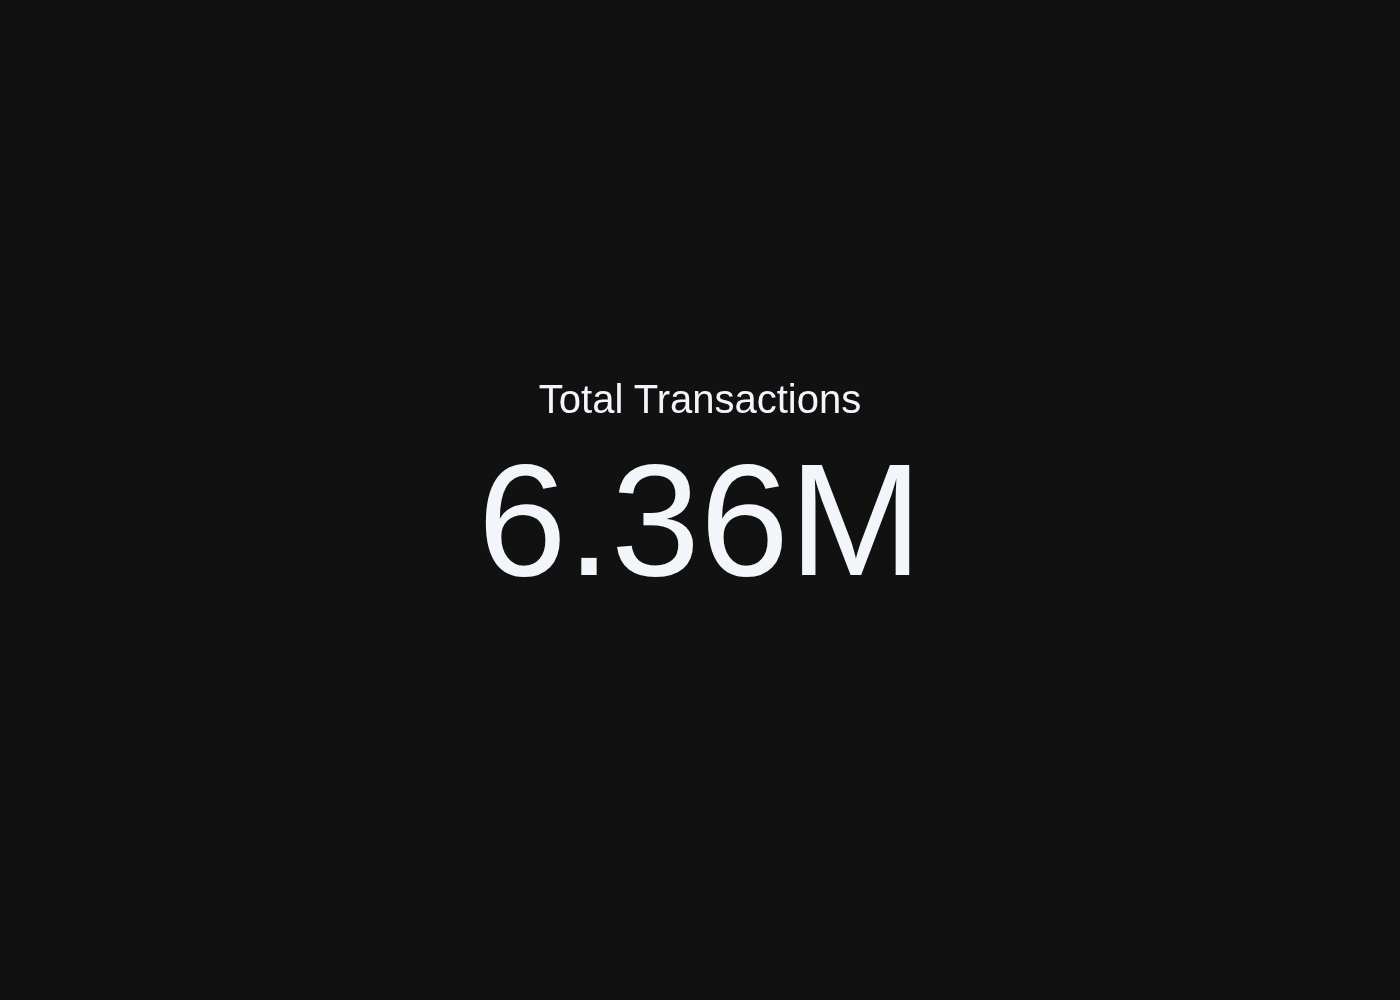

('SELECT COUNT(*) FROM trxns',    COUNT(*)
0   6362620, Figure({
    'data': [{'delta': {'increasing': {'color': 'RebeccaPurple'}, 'reference': 0},
              'gauge': {'axis': {'range': [None, 12725240], 'visible': False},
                        'bar': {'color': 'lightblue'},
                        'bgcolor': 'lightgray',
                        'bordercolor': 'gray',
                        'borderwidth': 2,
                        'steps': [{'color': 'lightgray', 'range': [0, 3181310.0]},
                                  {'color': 'lightblue', 'range': [3181310.0, 6362620]}]},
              'mode': 'number',
              'title': {'text': 'Total Transactions'},
              'type': 'indicator',
              'value': 6362620}],
    'layout': {'template': '...'}
}))


In [20]:
# Ask a question
print(vn.ask("How many trxns in total?"))

SQL Prompt: [{'role': 'system', 'content': 'You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE trxns ("step" INTEGER, "type" TEXT, "amount" REAL, "nameOrig" TEXT, "oldbalanceOrg" REAL, "newbalanceOrig" REAL, "nameDest" TEXT, "oldbalanceDest" REAL, "newbalanceDest" REAL, "isFraud" INTEGER, "isFlaggedFraud" INTEGER)\n\n\n===Additional Context \n\n\n    The trxns table contains transaction records between accounts. Each row represents a single transaction.\n\n    Columns:\n    - step: Simulation step (an integer indicating the order of the transaction over time).\n    - type: Type of transaction (e.g., \'PAYMENT\', \'TRANSFER\', \'CASH_OUT\', etc.).\n    - amount: Transaction amount in USD.\n    - nameOrig: Unique identifier of the originator (sender) account.\n    - oldbalanceOrg: Account balance of the originator

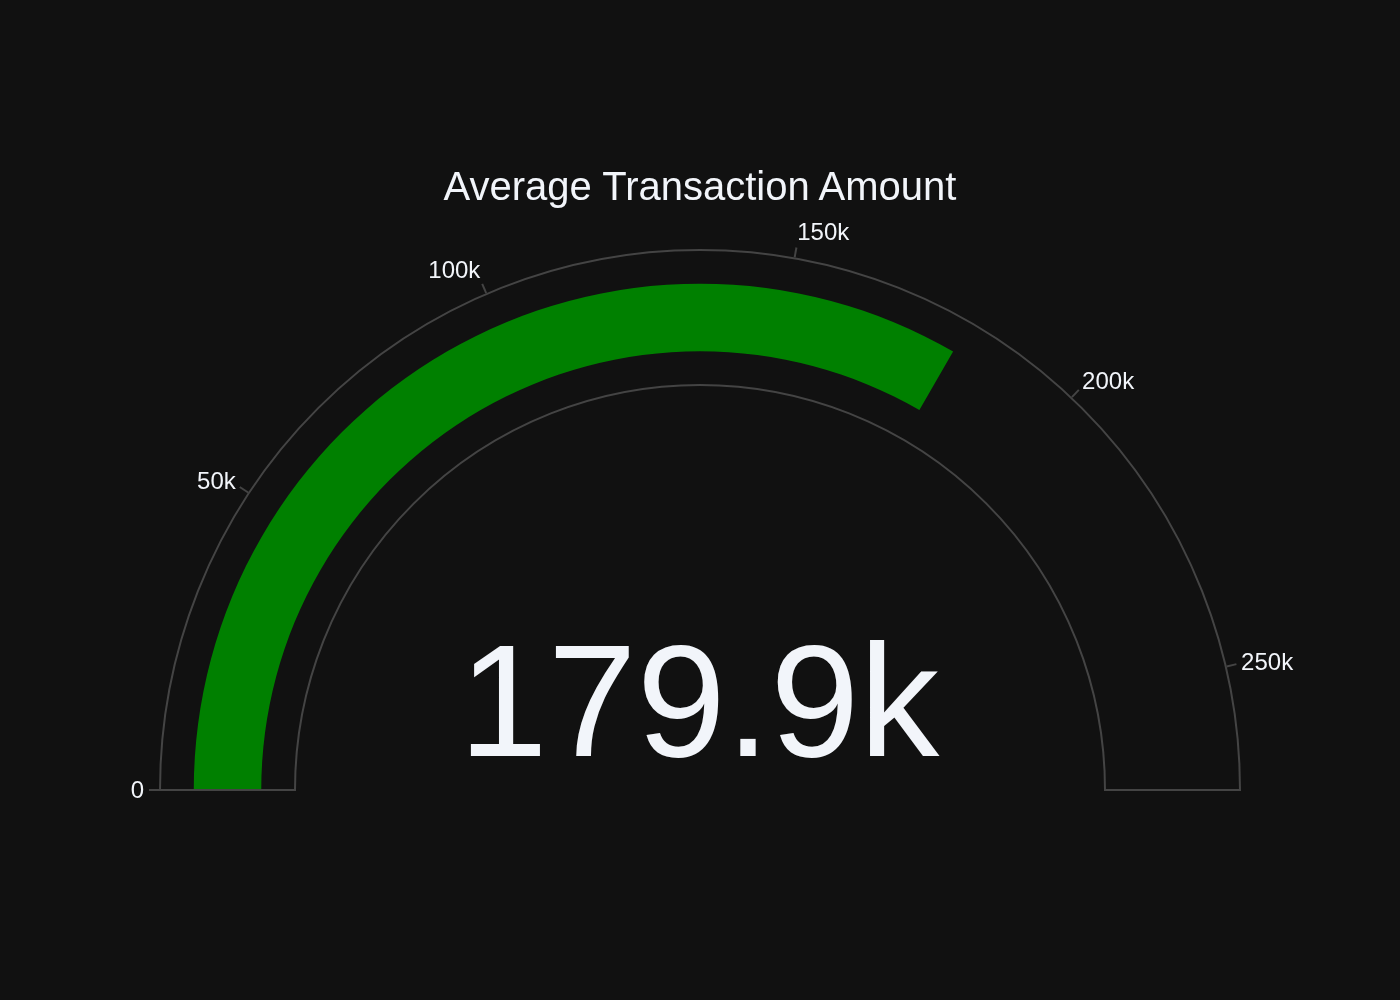

('SELECT AVG(amount) FROM trxns',      AVG(amount)
0  179861.903549, Figure({
    'data': [{'mode': 'gauge+number',
              'title': {'text': 'Average Transaction Amount'},
              'type': 'indicator',
              'value': 179861.90354913071}],
    'layout': {'template': '...'}
}))


In [10]:
# Ask a question
print(vn.ask("What is the average trxn amount?"))

SQL Prompt: [{'role': 'system', 'content': 'You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE trxns ("step" INTEGER, "type" TEXT, "amount" REAL, "nameOrig" TEXT, "oldbalanceOrg" REAL, "newbalanceOrig" REAL, "nameDest" TEXT, "oldbalanceDest" REAL, "newbalanceDest" REAL, "isFraud" INTEGER, "isFlaggedFraud" INTEGER)\n\n\n===Additional Context \n\n\n    The trxns table contains transaction records between accounts. Each row represents a single transaction.\n\n    Columns:\n    - step: Simulation step (an integer indicating the order of the transaction over time).\n    - type: Type of transaction (e.g., \'PAYMENT\', \'TRANSFER\', \'CASH_OUT\', etc.).\n    - amount: Transaction amount in USD.\n    - nameOrig: Unique identifier of the originator (sender) account.\n    - oldbalanceOrg: Account balance of the originator

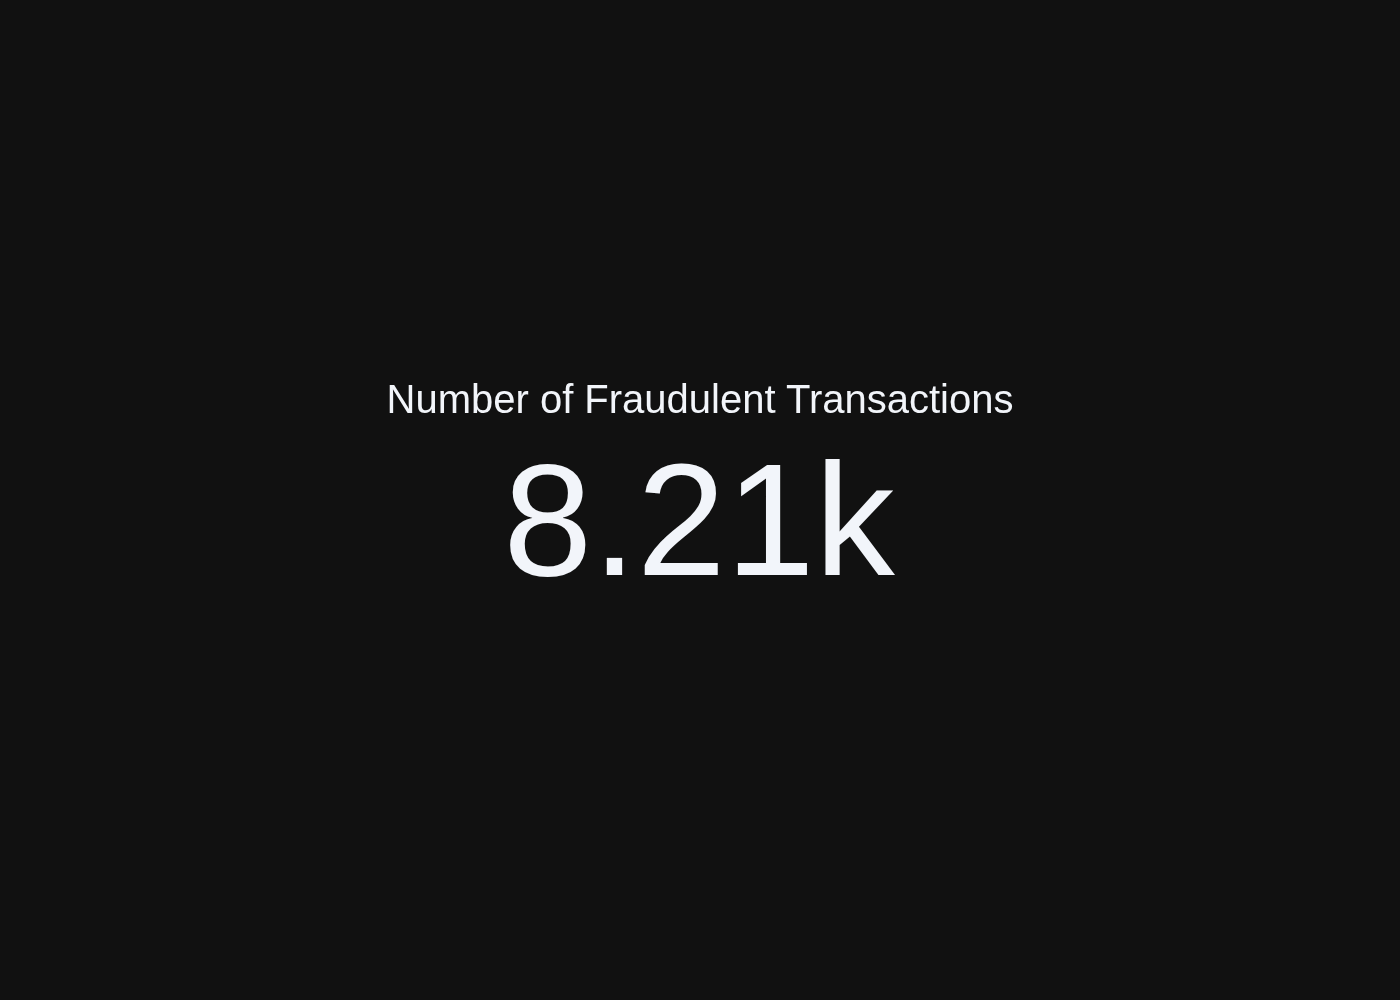

('SELECT COUNT(*) FROM trxns WHERE isFraud = 1',    COUNT(*)
0      8213, Figure({
    'data': [{'mode': 'number',
              'title': {'text': 'Number of Fraudulent Transactions'},
              'type': 'indicator',
              'value': 8213}],
    'layout': {'height': 200, 'template': '...', 'width': 400}
}))


In [11]:
# Ask a question
print(vn.ask("How many fraudulent trxns are there?"))

SQL Prompt: [{'role': 'system', 'content': 'You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE trxns ("step" INTEGER, "type" TEXT, "amount" REAL, "nameOrig" TEXT, "oldbalanceOrg" REAL, "newbalanceOrig" REAL, "nameDest" TEXT, "oldbalanceDest" REAL, "newbalanceDest" REAL, "isFraud" INTEGER, "isFlaggedFraud" INTEGER)\n\n\n===Additional Context \n\n\n    This dataset is used to answer questions about the transactions (trxns) information.\n    \n\n\n    The trxns table contains transaction records between accounts. Each row represents a single transaction.\n\n    Columns:\n    - step: Simulation step (an integer indicating the order of the transaction over time).\n    - type: Type of transaction (e.g., \'PAYMENT\', \'TRANSFER\', \'CASH_OUT\', etc.).\n    - amount: Transaction amount in USD.\n    - nameOrig: Unique id

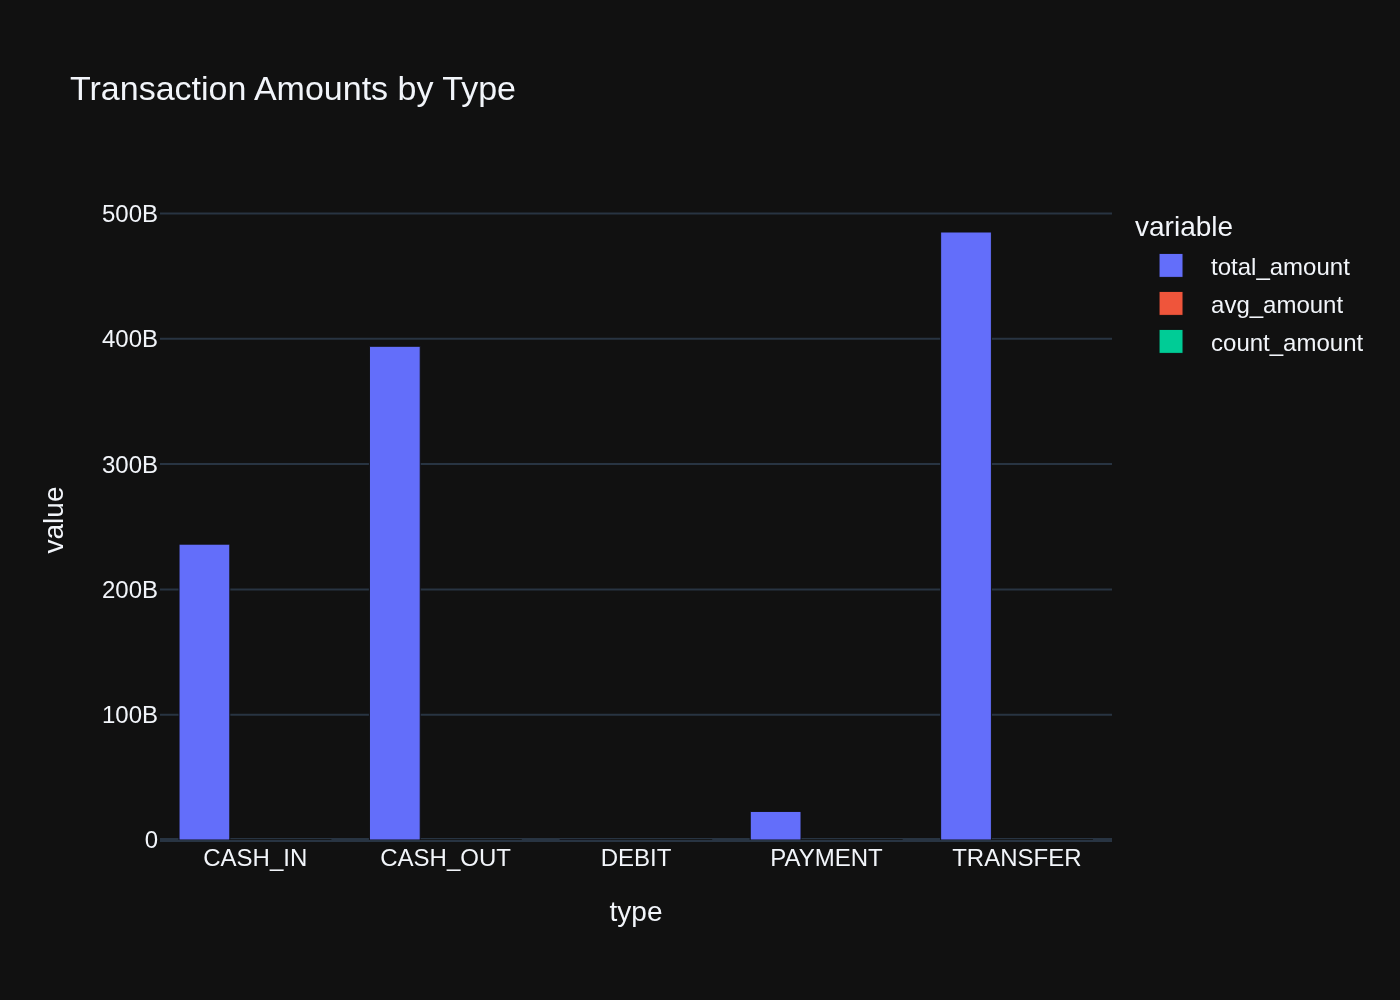

('SELECT \n  type,\n  SUM(amount) AS total_amount,\n  AVG(amount) AS avg_amount,\n  COUNT(*) AS count_amount\nFROM \n  trxns\nWHERE \n  amount > 10000\nGROUP BY \n  type',        type  total_amount     avg_amount  count_amount
0   CASH_IN  2.361274e+11  174703.178858       1351592
1  CASH_OUT  3.940478e+11  182030.145648       2164739
2     DEBIT  1.060815e+08   28034.221993          3784
3   PAYMENT  2.280407e+10   22148.712057       1029589
4  TRANSFER  4.852613e+11  921105.392165        526825, Figure({
    'data': [{'alignmentgroup': 'True',
              'hovertemplate': 'variable=total_amount<br>type=%{x}<br>value=%{y}<extra></extra>',
              'legendgroup': 'total_amount',
              'marker': {'color': '#636efa', 'pattern': {'shape': ''}},
              'name': 'total_amount',
              'offsetgroup': 'total_amount',
              'orientation': 'v',
              'showlegend': True,
              'textposition': 'auto',
              'type': 'bar',
              '

In [18]:
# Ask a question
print(vn.ask("""Filter (> 10_000) and group transactions by type, 
              then compute total, average, and count of amounts, 
              returning only high-value groups? """))